# Radial spectral budgets of the NHQG vorticity equation
### Ghost-clean energy & enstrophy cascades + analysis-window convergence study

This notebook consolidates the 2026-07 spectral-budget analysis. Every figure is
regenerated **live** from the precomputed `budget.npz` archives in this directory
(`analysis/spectral_budget/`), so you can re-run top-to-bottom and tweak freely.
Windows are computed from checkpoints by `scripts/spectral_budget_radial.py`
(numpy-only, self-testing); this notebook only *reads* those archives.

**Data sources**

| chain | run directory (under `output/`) | epochs analyzed | product path |
|---|---|---|---|
| 128²×256 | `output_combined_Nx128_Nz256_t40_to_t70_sub4_23rule_stack13_snap01` | t = 40–120, Δt = 0.25 | 2/3-rule (solver-matching) |
| 64²×256 from-start | `output_miquel_zero_tilt_galerkin_ars222_evolvemean_balancedsbp2pc_flux_subcycle4_fromstart_Nx64_Nz256_dt5e5_t80_snap01` | t = 0.25–80 | 3/2-rule (era-correct; validated vs `nhqg.spectral` to 5×10⁻¹⁶) |
| 256²×256 | `output_combined_Nx256_Nz256_t41_to_t58_sub4_23rule_stack13_snap01` | t = 41–63 | 2/3-rule |

**TL;DR (established in the sections below)**

1. **Dual cascade, quantified** (128², t=80–120): inverse energy cascade
   Π_E ≈ −1300 through k ≈ 0.2 into the box-scale condensate (balanced there by
   Laplacian dissipation — no drag); forward enstrophy cascade Π_Z ≈ +770 at
   k ≈ 2.5; ~8% of enstrophy injection exits through the 2/3 mask. Budgets close.
2. **Analysis window for the 128² chain: use t = 80–120.** Horizontal KE and
   scalar-variance spectra are near-stationary there (×1.5 / ×2.4 worst-shell
   between halves), but the **vertical KE Chebyshev tail never converges**
   (×35 between halves, after filling ×6000 since t=40–80) — no fully
   vertically-converged window exists on this chain.
3. **Not developed by t = 20.** At t=20 the flow carries <10% of its mature KE;
   spectra, fluxes and the condensate all grow monotonically through t ≈ 80.
   The t=20–40 window mixes epochs and should not be used.
4. **The 256² chain (t=43–63) is the cleanest dataset**: all three spectral
   criteria converge between its halves, the vertical spectrum is smooth with no
   rough tail, and the ghost is only ~3×10⁷ — but the fluxes still intensify
   ~35% between halves (it inherited a still-charging state).
5. **Cross-resolution**: 128² and 256² horizontal spectra collapse (×1.26 /
   ×1.17 worst-shell). The 64² run's θ-variance is inflated ×2–10 for k ≳ 0.8
   and its forward enstrophy flux is ~50% stronger — the frozen masked band
   k ∈ (2.74, 3.16) is the suspect (relevant to the Nusselt gap).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 110
BASE = Path(".")   # this notebook lives in analysis/spectral_budget/

ALL = ["window_t40_t80", "window_t80_t120", "window_t40_t120",
       "window_t80_t100", "window_t100_t120b",
       "n64_t10_t20", "n64_t20_t30", "n64_t30_t40", "n64_t40_t80",
       "n256_t43_t53", "n256_t53_t63", "n256_t43_t63"]

def load(name):
    with np.load(BASE / name / "budget.npz") as z:
        return {k: z[k] for k in z.files}

WIN = {nm: load(nm) for nm in ALL}

print("window inventory (first line of each summary.txt):\n")
for nm in ALL:
    line1 = (BASE / nm / "summary.txt").read_text().splitlines()[0]
    print(f"  {nm:20s} {line1}")

window inventory (first line of each summary.txt):

  window_t40_t80       window: t = 40.25 .. 80.00, 160 snapshots, Nx=128, Nz=256
  window_t80_t120      window: t = 80.00 .. 120.00, 161 snapshots, Nx=128, Nz=256
  window_t40_t120      window: t = 40.25 .. 120.00, 320 snapshots, Nx=128, Nz=256
  window_t80_t100      window: t = 80.00 .. 100.00, 81 snapshots, Nx=128, Nz=256
  window_t100_t120b    window: t = 100.00 .. 120.00, 81 snapshots, Nx=128, Nz=256
  n64_t10_t20          window: t = 10.00 .. 20.00, 41 snapshots, Nx=64, Nz=256
  n64_t20_t30          window: t = 20.00 .. 30.00, 41 snapshots, Nx=64, Nz=256
  n64_t30_t40          window: t = 30.00 .. 40.00, 41 snapshots, Nx=64, Nz=256
  n64_t40_t80          window: t = 40.00 .. 80.00, 161 snapshots, Nx=64, Nz=256
  n256_t43_t53         window: t = 43.00 .. 53.00, 41 snapshots, Nx=256, Nz=256
  n256_t53_t63         window: t = 53.00 .. 63.00, 41 snapshots, Nx=256, Nz=256
  n256_t43_t63         window: t = 43.00 .. 63.00, 81 snapshots

## 0. Method

With $\hat\psi = -\hat q/|k|^2$ ($\beta=0$, $L_d=\infty$), the horizontal-spectral
vorticity equation at each depth is

$$\partial_t \hat q \;=\; \underbrace{\widehat{-J(\psi,q)}}_{\hat T_{\rm adv}}
\;+\; \underbrace{\partial_Z \hat w}_{\hat T_{\rm str}}
\;-\; \underbrace{\nu |k|^2 \hat q}_{\rm dissipation}.$$

**Shell budgets.** Multiply by $-\hat\psi^*$ (energy) or $+\hat q^*$ (enstrophy),
take the real part, depth-integrate with Clenshaw–Curtis weights on the CGL grid,
and sum over radial shells $k \in [nk_0 - k_0/2,\, nk_0 + k_0/2)$ with
$k_0 = 2\pi/L \approx 0.1305$:

$$E(k) = \sum_{\rm shell} \tfrac12 |k|^2 |\hat\psi|^2, \qquad
T_{E,\bullet}(k) = -\,\mathrm{Re}\!\sum_{\rm shell} \hat\psi^* \hat T_\bullet,$$
$$\mathcal{Z}(k) = \sum_{\rm shell} \tfrac12 |\hat q|^2, \qquad
T_{Z,\bullet}(k) = +\,\mathrm{Re}\!\sum_{\rm shell} \hat q^* \hat T_\bullet.$$

**Fluxes.** $\Pi(k) = -\sum_{k' \le k} T_{\rm adv}(k')$. $\Pi_E < 0$ means
inverse cascade; $\Pi_Z > 0$ means forward cascade.

**Hygiene — four things that make these budgets trustworthy:**

1. **Ghost projection.** The rfft2 $k_y=0$ and Nyquist columns are
   Hermitian-symmetrized *before any inner product*. The anti-Hermitian ghost
   (see `hermitian_ghost.md`) reaches ~2×10¹⁹ on the 128² chain by t=120 and
   would otherwise dominate every Parseval-style sum. The 256² chain's ghost is
   only ~3×10⁷ (reset by the t=41 upsampling).
2. **Solver-matching products.** The 2/3-rule windows use the unpadded masked
   product path exactly as the solver does; the 64² from-start run predates the
   2/3 switch and is analyzed with the padded 3/2 path (cross-checked against
   `nhqg.spectral.conservative_flux_divergence_dealiased` to rel. 5×10⁻¹⁶).
3. **Closure-inferred stretching (energy only).** The raw sampled
   $-\mathrm{Re}\langle\hat\psi^*\partial_Z\hat w\rangle$ is useless at
   $k \lesssim 0.5$ from 0.25-spaced checkpoints: the $k<0.35$ modes are
   oscillatory (periods ~0.3) and alias at that cadence, with swings ~10⁵
   against a signal ~10³. The estimator used instead is per-shell
   (linear-fit $dE/dt$) − $T_{\rm adv}$ − $T_{\rm diss}$; raw and inferred
   agree for $k > 0.5$, which validates it.
4. **Barotropic split.** For the depth-averaged streamfunction the stretching
   term depth-integrates to exactly zero ($w=0$ at the walls) — verified to
   6×10⁻⁸ — so the barotropic budget is advection vs dissipation only.

**To (re)generate a window archive** (CPU, ~2 min per 161 snapshots):

```bash
JAX_PLATFORMS=cpu PYTHONPATH=. python scripts/spectral_budget_radial.py \
  --run-dir output/output_combined_Nx128_Nz256_t40_to_t70_sub4_23rule_stack13_snap01 \
  --t-min 80 --t-max 120 --dealias 23 --out analysis/spectral_budget/window_t80_t120
```

In [2]:
KC_ONSET = 1.3048   # linear-onset wavenumber (dotted line in plots)

def sel_of(z):
    """Shell indices retained by the analysis (drop empty k=0 bin)."""
    return np.where(z["in_cut"])[0][1:]

def inferred_stretch(z):
    """Closure-inferred energy stretching: per-shell dE/dt fit - adv - diss."""
    slope = np.polyfit(z["ts_t"], z["spec_series_E"].astype(float), 1)[0]
    return slope, slope - z["E_adv"] - z["E_diss"]

def style(ax, z, xlab=True):
    ax.axvline(KC_ONSET, color="0.6", lw=0.8, ls=":")
    ax.axvline(float(z["k_cut"]), color="0.6", lw=0.8, ls="--")
    ax.grid(alpha=0.25, which="both")
    if xlab:
        ax.set_xlabel(r"$k$")

def energy_budget(z, title):
    s = sel_of(z); k = z["k_bins"][s]
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))

    ax = axs[0]                                   # spectra
    E, Ebt = z["E_spec"][s], z["E_bt_spec"][s]
    Ebc = np.maximum(E - Ebt, 1e-300)
    ax.loglog(k, E, "k-", lw=1.8, label=r"$E(k)$ total")
    ax.loglog(k, Ebt, "C0-", lw=1.4, label=r"$E_{bt}(k)$ barotropic")
    ax.loglog(k, Ebc, "C3-", lw=1.4, label=r"$E_{bc}(k)$ baroclinic")
    i0 = max(1, int(np.argmax(E)))
    for slope_ref, lab, c in ((-5/3, r"$k^{-5/3}$", "0.4"), (-3.0, r"$k^{-3}$", "0.7")):
        ref = E[i0] * (k / k[i0]) ** slope_ref
        ax.loglog(k, ref, color=c, lw=0.8, ls="--")
        ax.annotate(lab, (k[-1], ref[-1]), fontsize=8, color=c)
    style(ax, z); ax.set_ylabel(r"$E(k)$")
    ax.set_title("KE spectra (time-averaged)"); ax.legend(fontsize=8)

    ax = axs[1]                                   # premultiplied shell budget
    for nm, lab, c, lw, al in (
            ("E_adv", "advection (transfer)", "C0", 1.5, 1.0),
            ("E_diss", r"dissipation $-\nu k^2$", "C2", 1.5, 1.0),
            ("E_str", r"stretching, raw sample mean (aliased at low $k$)", "C3", 0.9, 0.55)):
        ax.semilogx(k, k * z[nm][s], color=c, lw=lw, alpha=al, label=lab)
        ax.fill_between(k, k * (z[nm] - z["se_" + nm])[s],
                        k * (z[nm] + z["se_" + nm])[s], color=c, alpha=0.12, lw=0)
    slope, inferred = inferred_stretch(z)
    ax.semilogx(k, k * inferred[s], "C1-", lw=1.9, label="stretching (closure-inferred)")
    ax.semilogx(k, k * slope[s], "k--", lw=1.0, label=r"$dE/dt$ (fit)")
    ylim = 1.4 * max(np.max(np.abs(k * z["E_adv"][s])),
                     np.max(np.abs(k * z["E_diss"][s])),
                     np.max(np.abs(k * inferred[s])))
    ax.set_ylim(-ylim, ylim); ax.axhline(0, color="0.5", lw=0.6)
    style(ax, z); ax.set_ylabel(r"$k\,T_E(k)$  (premultiplied)")
    ax.set_title("KE shell budget"); ax.legend(fontsize=8)

    ax = axs[2]                                   # fluxes
    PiE = -np.cumsum(z["E_adv"][s])
    pi_se = np.sqrt(np.cumsum(z["se_E_adv"][s] ** 2))
    ax.semilogx(k, PiE, "C0-", lw=1.8, label=r"$\Pi_E(k)$ advective flux")
    ax.fill_between(k, PiE - pi_se, PiE + pi_se, color="C0", alpha=0.18, lw=0)
    ax.semilogx(k, np.cumsum(inferred[s]), "C1-", lw=1.4,
                label=r"$\int_0^k$ stretching input (closure-inferred)")
    ax.semilogx(k, -np.cumsum(z["E_diss"][s]), "C2-", lw=1.4,
                label=r"$-\int_0^k$ dissipation")
    ax.axhline(0, color="0.5", lw=0.6)
    style(ax, z); ax.set_ylabel("cumulative rate")
    ax.set_title(r"KE flux: $\Pi_E<0$ = inverse cascade"); ax.legend(fontsize=8)

    fig.suptitle(title, y=1.02); fig.tight_layout(); plt.show()

def enstrophy_budget(z, title):
    s = sel_of(z); k = z["k_bins"][s]
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))

    ax = axs[0]
    ax.loglog(k, z["Z_spec"][s], "k-", lw=1.8, label=r"$\mathcal{Z}(k)$")
    style(ax, z); ax.set_ylabel(r"$\mathcal{Z}(k)$")
    ax.set_title("Enstrophy spectrum"); ax.legend(fontsize=8)

    ax = axs[1]
    for nm, lab, c in (("Z_adv", "advection (transfer)", "C0"),
                       ("Z_str", r"stretching $\Re\langle q^*\partial_Z w\rangle$", "C3"),
                       ("Z_diss", r"dissipation $-\nu k^2$", "C2")):
        ax.semilogx(k, k * z[nm][s], color=c, lw=1.5, label=lab)
        ax.fill_between(k, k * (z[nm] - z["se_" + nm])[s],
                        k * (z[nm] + z["se_" + nm])[s], color=c, alpha=0.18, lw=0)
    tot = (z["Z_adv"] + z["Z_str"] + z["Z_diss"])[s]
    ax.semilogx(k, k * tot, "k--", lw=1.0, label="sum (net tendency)")
    ax.axhline(0, color="0.5", lw=0.6)
    style(ax, z); ax.set_ylabel(r"$k\,T_Z(k)$  (premultiplied)")
    ax.set_title("Enstrophy shell budget"); ax.legend(fontsize=8)

    ax = axs[2]
    PiZ = -np.cumsum(z["Z_adv"][s])
    piz_se = np.sqrt(np.cumsum(z["se_Z_adv"][s] ** 2))
    ax.semilogx(k, PiZ, "C0-", lw=1.8, label=r"$\Pi_Z(k)$ advective flux")
    ax.fill_between(k, PiZ - piz_se, PiZ + piz_se, color="C0", alpha=0.18, lw=0)
    ax.semilogx(k, np.cumsum(z["Z_str"][s]), "C3-", lw=1.4,
                label=r"$\int_0^k$ stretching input")
    ax.semilogx(k, -np.cumsum(z["Z_diss"][s]), "C2-", lw=1.4,
                label=r"$-\int_0^k$ dissipation")
    ax.axhline(0, color="0.5", lw=0.6)
    style(ax, z); ax.set_ylabel("cumulative rate")
    ax.set_title(r"Enstrophy flux: $\Pi_Z>0$ = forward cascade"); ax.legend(fontsize=8)

    fig.suptitle(title, y=1.02); fig.tight_layout(); plt.show()

def barotropic_budget(z, title):
    s = sel_of(z); k = z["k_bins"][s]
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))

    ax = axs[0]
    ax.semilogx(k, k * z["Ebt_adv"][s], "C0-", lw=1.6, label="advective transfer into bt mode")
    ax.fill_between(k, k * (z["Ebt_adv"] - z["se_Ebt_adv"])[s],
                    k * (z["Ebt_adv"] + z["se_Ebt_adv"])[s], color="C0", alpha=0.18, lw=0)
    ax.semilogx(k, k * z["Ebt_diss"][s], "C2-", lw=1.4, label="bt dissipation")
    ax.semilogx(k, k * (z["Ebt_adv"] + z["Ebt_diss"])[s], "k--", lw=1.0, label="sum")
    ax.axhline(0, color="0.5", lw=0.6)
    style(ax, z); ax.set_ylabel(r"$k\,T_{E_{bt}}(k)$")
    ax.set_title("Barotropic KE budget\n(stretching $\\equiv 0$: $w$ vanishes at walls)")
    ax.legend(fontsize=8)

    ax = axs[1]
    Pib = -np.cumsum(z["Ebt_adv"][s])
    pib_se = np.sqrt(np.cumsum(z["se_Ebt_adv"][s] ** 2))
    ax.semilogx(k, Pib, "C0-", lw=1.8, label=r"$\Pi_{E_{bt}}(k)$")
    ax.fill_between(k, Pib - pib_se, Pib + pib_se, color="C0", alpha=0.18, lw=0)
    ax.axhline(0, color="0.5", lw=0.6)
    style(ax, z); ax.set_ylabel("cumulative rate")
    ax.set_title("Barotropic KE flux (the LSV pipeline)"); ax.legend(fontsize=8)

    ax = axs[2]
    ax.plot(z["ts_t"], z["ts_E_bt"], "C0-", lw=1.2, label=r"$E_{bt}$")
    ax.plot(z["ts_t"], z["ts_E_tot"], "k-", lw=1.0, alpha=0.7, label=r"$E$ total")
    ax2 = ax.twinx()
    ax2.plot(z["ts_t"], z["ts_E_str_sum"], "C3-", lw=0.7, alpha=0.6)
    ax2.set_ylabel(r"$\sum_k T_{E,str}$ (osc.)", color="C3", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="C3", labelsize=7)
    ax.grid(alpha=0.25); ax.set_xlabel(r"$t$"); ax.set_ylabel("energy")
    ax.set_title("Time series (LSV unsteadiness)"); ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(title, y=1.02); fig.tight_layout(); plt.show()

COLORS = ["k", "C0", "C3", "C2", "C4", "C5"]

def overlay(wins, title):
    """6-panel window comparison: E(k), Th(k), E_m, Th_m/W_m, Pi_E, Pi_Z."""
    fig, axs = plt.subplots(2, 3, figsize=(15.5, 8.6))
    for i, (lab, z) in enumerate(wins):
        s = sel_of(z); k = z["k_bins"][s]; c = COLORS[i]
        m = np.arange(len(z["vert_E"]))[1:]
        axs[0, 0].loglog(k, z["E_spec"][s], color=c, lw=1.5, label=lab)
        axs[0, 1].loglog(k, z["TH_spec"][s], color=c, lw=1.5, label=lab)
        axs[0, 2].loglog(m, z["vert_E"][1:], color=c, lw=1.5, label=lab)
        axs[1, 0].loglog(m, z["vert_TH"][1:], color=c, lw=1.5, label=lab)
        axs[1, 0].loglog(m, z["vert_W"][1:], color=c, lw=0.7, ls=":", alpha=0.7)
        axs[1, 1].semilogx(k, -np.cumsum(z["E_adv"][s]), color=c, lw=1.5, label=lab)
        axs[1, 2].semilogx(k, -np.cumsum(z["Z_adv"][s]), color=c, lw=1.5, label=lab)
    for r, cidx, xl, yl, ttl in (
            (0, 0, r"$k$", r"$E(k)$", "Horizontal KE spectra"),
            (0, 1, r"$k$", r"$\frac{1}{2}\langle|\theta|^2\rangle(k)$", "Scalar variance spectra"),
            (0, 2, "Chebyshev degree $m$", r"$E_m$", "Vertical KE pseudo-spectra"),
            (1, 0, "Chebyshev degree $m$", r"$\Theta_m$ (solid), $W_m$ (dotted)",
             r"Vertical $\theta$ (and $w$) pseudo-spectra"),
            (1, 1, r"$k$", r"$\Pi_E(k)$", r"Energy flux ($<0$: inverse cascade)"),
            (1, 2, r"$k$", r"$\Pi_Z(k)$", r"Enstrophy flux ($>0$: forward cascade)")):
        ax = axs[r, cidx]
        ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
        ax.grid(alpha=0.25, which="both"); ax.legend(fontsize=8)
        if r == 1 and cidx >= 1:
            ax.axhline(0, color="0.6", lw=0.6)
    fig.suptitle(title, y=0.995); fig.tight_layout(); plt.show()

def conv_metrics(wins):
    """Worst-shell convergence ratio between consecutive windows.
    NOTE: max over all shells/modes — dominated by spectral tails; read
    alongside the figures, not instead of them."""
    print("max |log10 ratio| between consecutive windows (worst shell/mode):")
    for (la, za), (lb, zb) in zip(wins[:-1], wins[1:]):
        s = sel_of(za)
        out = []
        for key, lab in (("E_spec", "E(k)"), ("TH_spec", "Th(k)"),
                         ("vert_E", "E_m"), ("vert_TH", "Th_m")):
            xa, xb = (za[key][1:], zb[key][1:]) if key.startswith("vert") \
                else (za[key][s], zb[key][s])
            good = (xa > 0) & (xb > 0)
            r = np.max(np.abs(np.log10(xa[good] / xb[good])))
            out.append(f"{lab} x{10**r:.2f}")
        print(f"  {la:>10s} vs {lb:<10s}:  " + ",  ".join(out))

## 1. Flagship budget — 128²×256 chain, t = 80–120 (161 snapshots)

This is the recommended analysis window for the 128² chain (justified in §2).
How to read the three figures:

- **Energy** — the premultiplied shell budget shows advection *draining* the
  injection band (k ~ 0.8–2) and *depositing* at k ≲ 0.3; the flux panel shows
  Π_E ≈ −1300 through k ≈ 0.2: a strong **inverse cascade** feeding the
  box-scale condensate, balanced there by Laplacian dissipation acting on the
  condensate itself (this configuration has no large-scale drag). Read the
  **orange closure-inferred stretching**, not the faint red raw curve — the raw
  sampled conversion term is aliased at low k (method §0.3).
- **Enstrophy** — stretching injects at k ~ 1–3, advection carries it
  **forward** (Π_Z ≈ +770 at k ≈ 2.5) into the dissipation range. The transfer
  sum over retained shells is ≈ −200 rather than 0: that ~8% of injection is
  enstrophy carried past the 2/3 mask — the truncation sink.
- **Barotropic** — the LSV pipeline: baroclinic→barotropic transfer peaks at
  the condensate scale; its SE band is wide because the LSV is genuinely
  unsteady (E_bt swings 4×10³–1.2×10⁴ on ~10-unit timescales, right panel).

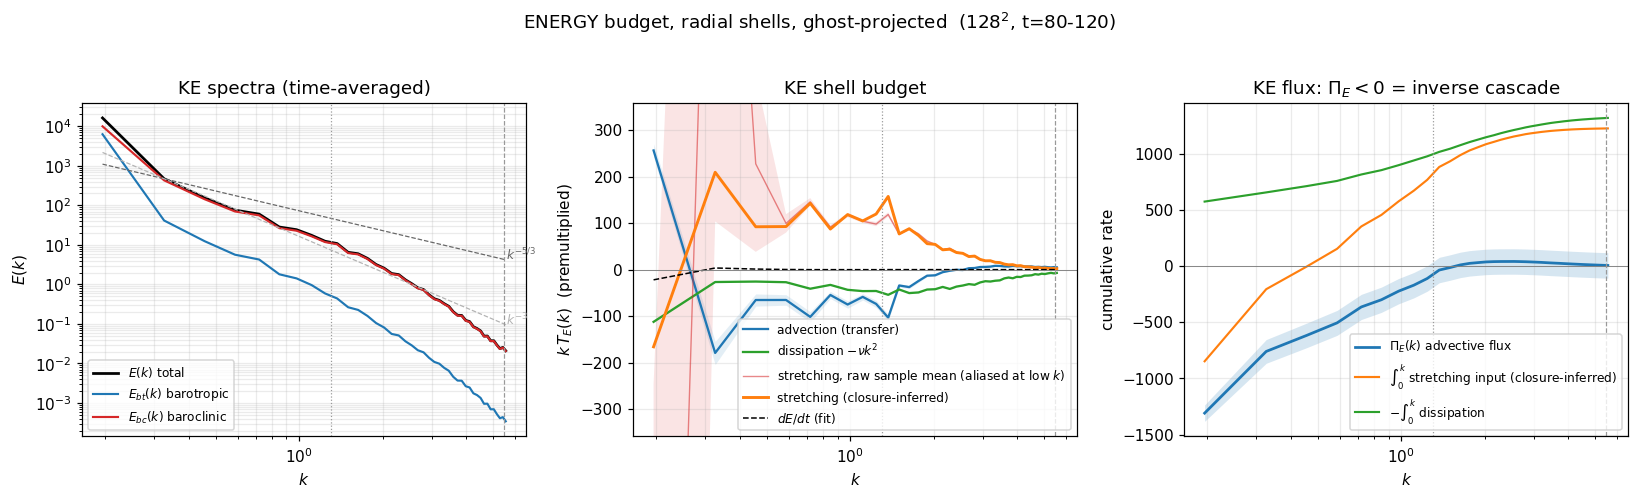

In [3]:
FLAG = WIN["window_t80_t120"]
energy_budget(FLAG, "ENERGY budget, radial shells, ghost-projected  (128$^2$, t=80-120)")

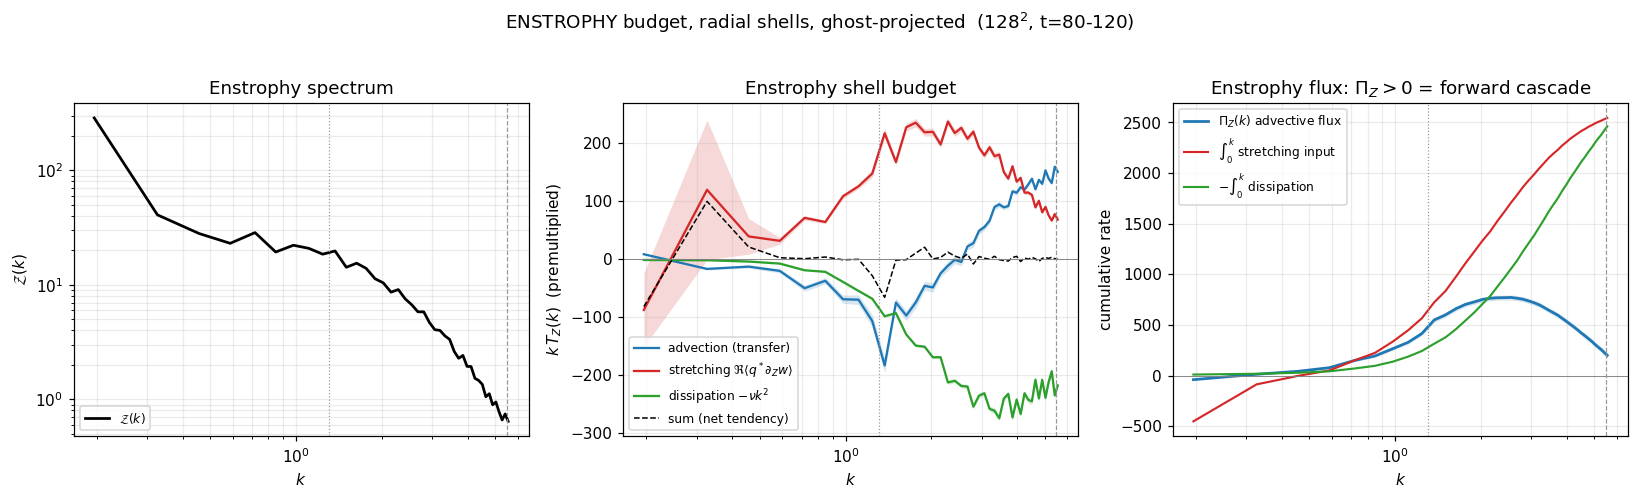

In [4]:
enstrophy_budget(FLAG, "ENSTROPHY budget, radial shells, ghost-projected  (128$^2$, t=80-120)")

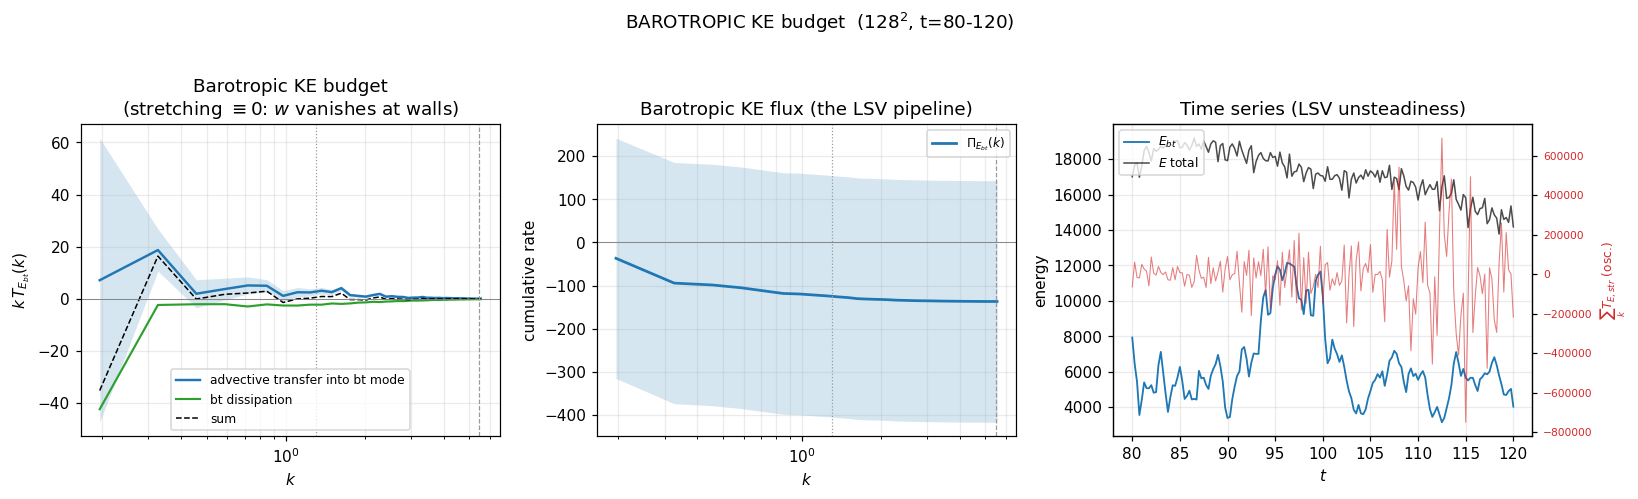

In [5]:
barotropic_budget(FLAG, "BAROTROPIC KE budget  (128$^2$, t=80-120)")

In [6]:
# headline numbers, computed from the archive
z = FLAG; s = sel_of(z); k = z["k_bins"][s]
PiE = -np.cumsum(z["E_adv"][s]); PiZ = -np.cumsum(z["Z_adv"][s])
slope, inferred = inferred_stretch(z)
ic = z["in_cut"]

print(f"Pi_E extreme : {PiE.min():+9.1f}  at k = {k[np.argmin(PiE)]:.3f}   (inverse cascade)")
print(f"Pi_Z extreme : {PiZ.max():+9.1f}  at k = {k[np.argmax(PiZ)]:.3f}   (forward cascade)")
print()
print("energy closure (sums over retained shells):")
print(f"  stretching (closure-inferred) = {np.sum(inferred[ic]):+9.1f}")
print(f"  dissipation                   = {np.sum(z['E_diss'][ic]):+9.1f}")
print(f"  advection                     = {np.sum(z['E_adv'][ic]):+9.1f}  (conservative, ~0)")
print(f"  dE/dt (fit)                   = {np.sum(slope[ic]):+9.1f}")
print()
print("enstrophy closure:")
print(f"  stretching = {np.sum(z['Z_str'][ic]):+9.1f} +/- {np.sqrt(np.sum(z['se_Z_str'][ic]**2)):.0f}")
print(f"  dissipation= {np.sum(z['Z_diss'][ic]):+9.1f}")
adv_sum = np.sum(z['Z_adv'][ic])
print(f"  advection  = {adv_sum:+9.1f}  -> mask/truncation sink "
      f"({100*abs(adv_sum)/np.sum(z['Z_str'][ic]):.0f}% of injection)")
print()
print("full hygiene report (summary.txt):\n")
print((BASE / "window_t80_t120" / "summary.txt").read_text())

Pi_E extreme :   -1308.7  at k = 0.196   (inverse cascade)
Pi_Z extreme :    +771.4  at k = 2.544   (forward cascade)

energy closure (sums over retained shells):
  stretching (closure-inferred) =   +1224.1
  dissipation                   =   -1317.3
  advection                     =      -5.0  (conservative, ~0)
  dE/dt (fit)                   =     -98.2

enstrophy closure:
  stretching =   +2543.3 +/- 497
  dissipation=   -2460.6
  advection  =    -199.5  -> mask/truncation sink (8% of injection)

full hygiene report (summary.txt):

window: t = 80.00 .. 120.00, 161 snapshots, Nx=128, Nz=256
ghost removed (max |anti-Hermitian ky=0| over window): 1.945e+19
state energy outside 2/3 mask (max fraction): 0.000e+00
depth-integrated stretching in bt budget (max, should be ~0): 5.825e-08
vertical Chebyshev tail (top 16 modes / total, max over window): q 2.694e-01, psi 6.781e-01
energy: sum adv = -5.0091e+00 +/- 1.13e+02 (|.|-sum 2.694e+03), sum stretch = -7.6767e+03 +/- 1.34e+04, sum diss =

**Caveats attached to this window** (from the hygiene report above):

- **q is vertically under-resolved**: up to 27% of q's vertical Chebyshev
  energy sits in the top 16 modes (ψ at low k: 68%) — the undamped vertical
  enstrophy cascade (no vertical diffusion on q). It inflates baroclinic E(k)
  at low k; the barotropic sector is immune. This is also why the vertical
  convergence criterion fails in §2.
- The raw energy-stretch sample mean (−7677 ± 13400) is *consistent with* the
  closure-inferred +1224 — the SE is that large because of the low-k aliasing;
  it is not a contradiction.

## 2. Analysis-window convergence — the 128² chain

Question: was t=80–120 the right window, and can t=40–80 (or the union
t=40–120) be used? Criteria (as specified): **horizontal KE spectrum**,
**scalar-variance spectrum**, and **vertical KE spectrum** converged between
sub-windows.

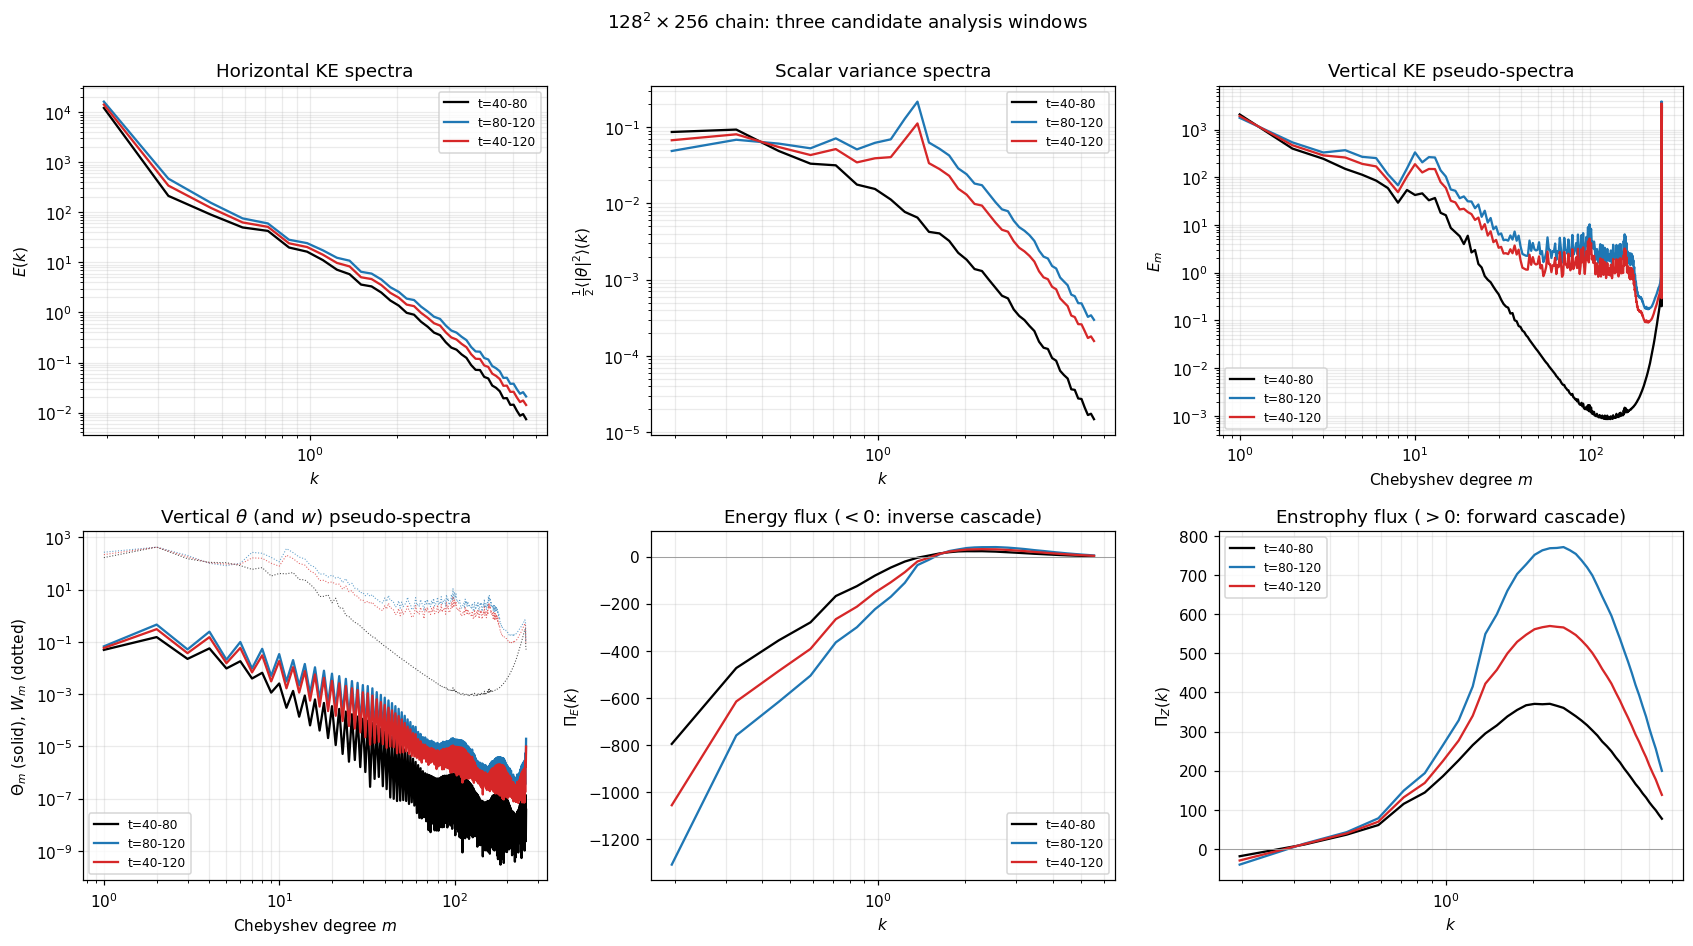

max |log10 ratio| between consecutive windows (worst shell/mode):
     t=40-80 vs t=80-120  :  E(k) x2.84,  Th(k) x33.09,  E_m x6125.02,  Th_m x1413.03
    t=80-120 vs t=40-120  :  E(k) x1.48,  Th(k) x1.93,  E_m x1.99,  Th_m x1.99


In [7]:
wins = [(lab, WIN[nm]) for lab, nm in (("t=40-80", "window_t40_t80"),
                                          ("t=80-120", "window_t80_t120"),
                                          ("t=40-120", "window_t40_t120"))]
overlay(wins, "128$^2\\times$256 chain: three candidate analysis windows")
conv_metrics(wins)

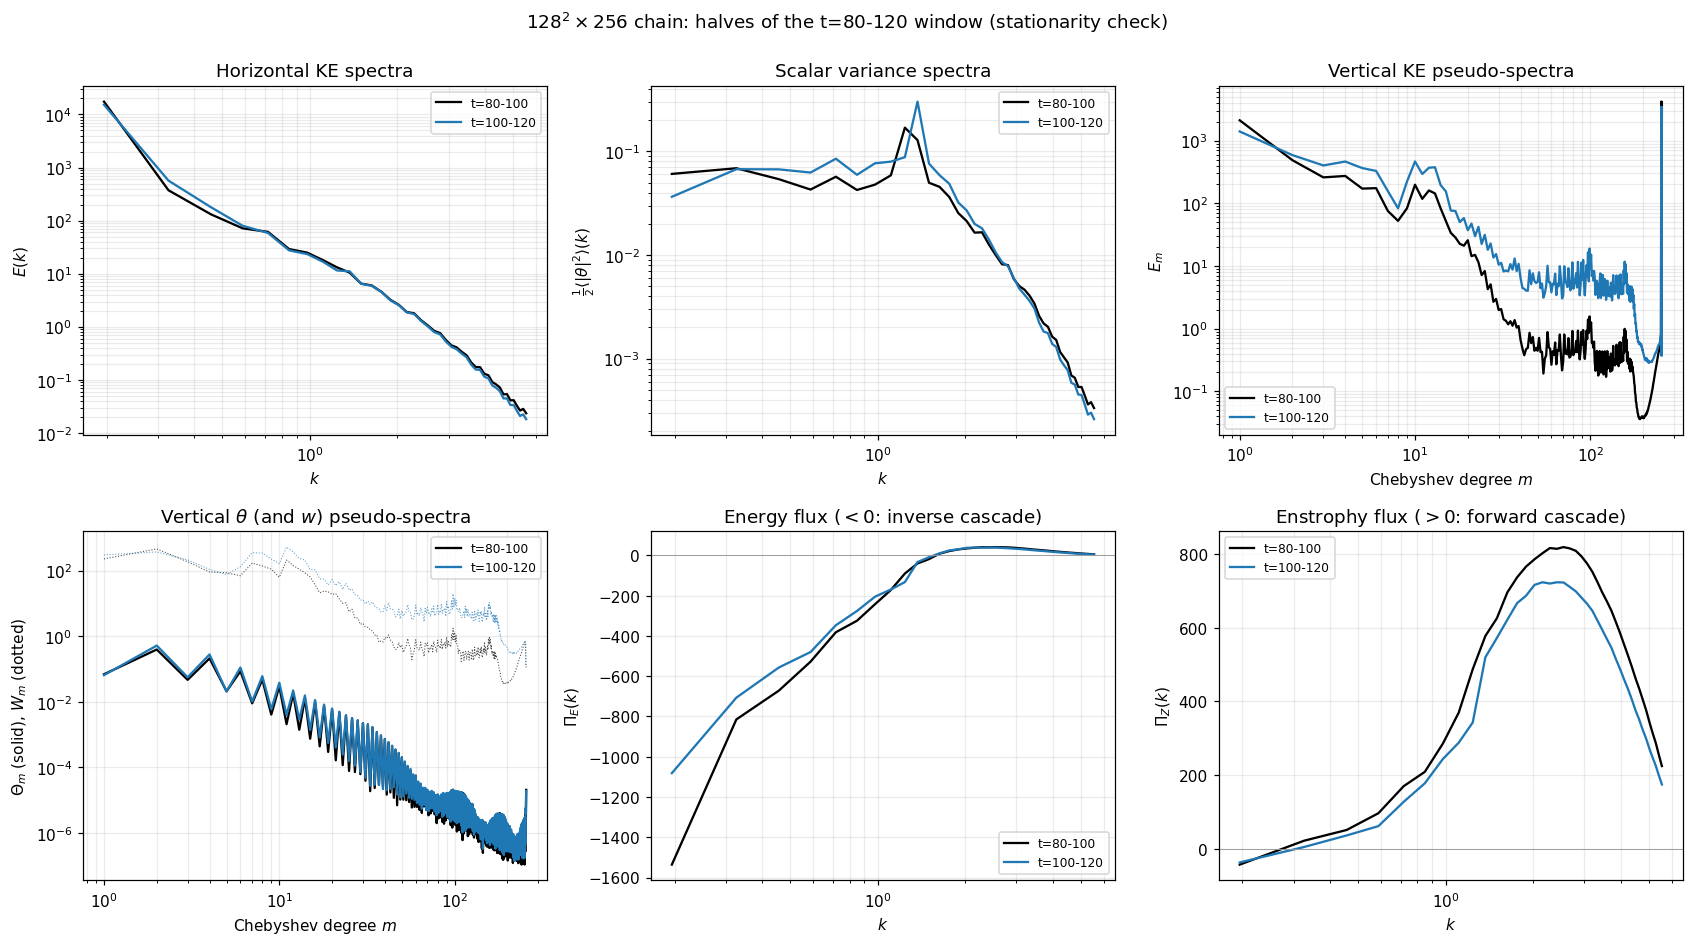

max |log10 ratio| between consecutive windows (worst shell/mode):
    t=80-100 vs t=100-120 :  E(k) x1.52,  Th(k) x2.35,  E_m x34.79,  Th_m x2.47


In [8]:
wins = [(lab, WIN[nm]) for lab, nm in (("t=80-100", "window_t80_t100"),
                                          ("t=100-120", "window_t100_t120b"))]
overlay(wins, "128$^2\\times$256 chain: halves of the t=80-120 window (stationarity check)")
conv_metrics(wins)

**Verdict for the 128² chain**

| criterion | 40–80 vs 80–120 | 80–100 vs 100–120 | status |
|---|---|---|---|
| horizontal E(k) | ×2.8 | **×1.5** | ✓ converged in 80–120 |
| scalar Θ(k) | ×33 | ×2.4 (shape-converged) | ✓ acceptable in 80–120 |
| vertical E_m | ×6000 | **×35** | ✗ never converges |

- t=40–80 is **not** similar to 80–120 — the whole flow is still intensifying
  (Π_E: −800 → −1309; Π_Z: +370 → +770). Averaging t=40–120 mixes epochs;
  its curves (green above) are just a weighted blend. **Don't use it.**
- **Use t = 80–120**, with the caveat that the vertical KE Chebyshev tail
  (m ≳ 30) is still filling ×35 between the halves even at t=120 — the
  undamped vertical layering cascade is secularly equilibrating. Horizontal-plane
  conclusions (cascade directions, fluxes, barotropic budget) are safe;
  anything sensitive to q's vertical fine structure carries this caveat.

## 3. Is the turbulence developed by t = 20? — No.

The 128² chain only exists from t=40 (born by upsampling the 64² state), so
this question is answered on the **64²×256 from-start run** (3/2-rule era,
analyzed with the era-correct 3/2 product path).

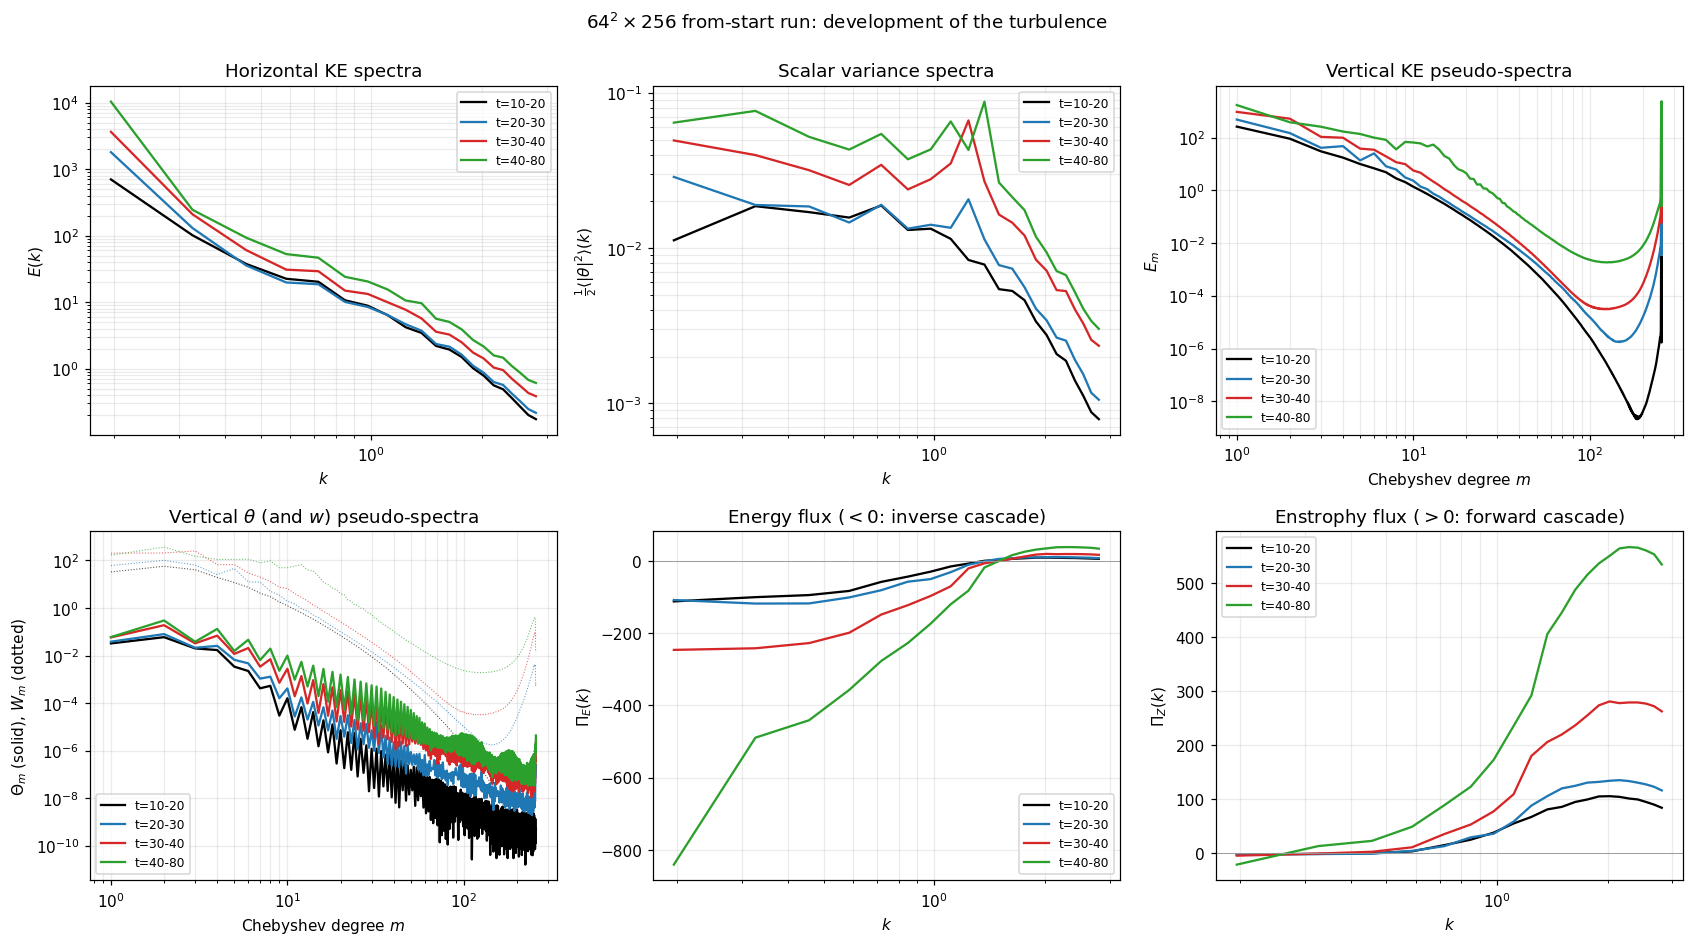

max |log10 ratio| between consecutive windows (worst shell/mode):
     t=10-20 vs t=20-30   :  E(k) x2.57,  Th(k) x2.56,  E_m x3983.17,  Th_m x634.87
     t=20-30 vs t=30-40   :  E(k) x2.02,  Th(k) x3.22,  E_m x34.11,  Th_m x40.74
     t=30-40 vs t=40-80   :  E(k) x2.85,  Th(k) x3.26,  E_m x61.38,  Th_m x5.18


In [9]:
wins = [(lab, WIN[nm]) for lab, nm in (("t=10-20", "n64_t10_t20"),
                                          ("t=20-30", "n64_t20_t30"),
                                          ("t=30-40", "n64_t30_t40"),
                                          ("t=40-80", "n64_t40_t80"))]
overlay(wins, "64$^2\\times$256 from-start run: development of the turbulence")
conv_metrics(wins)

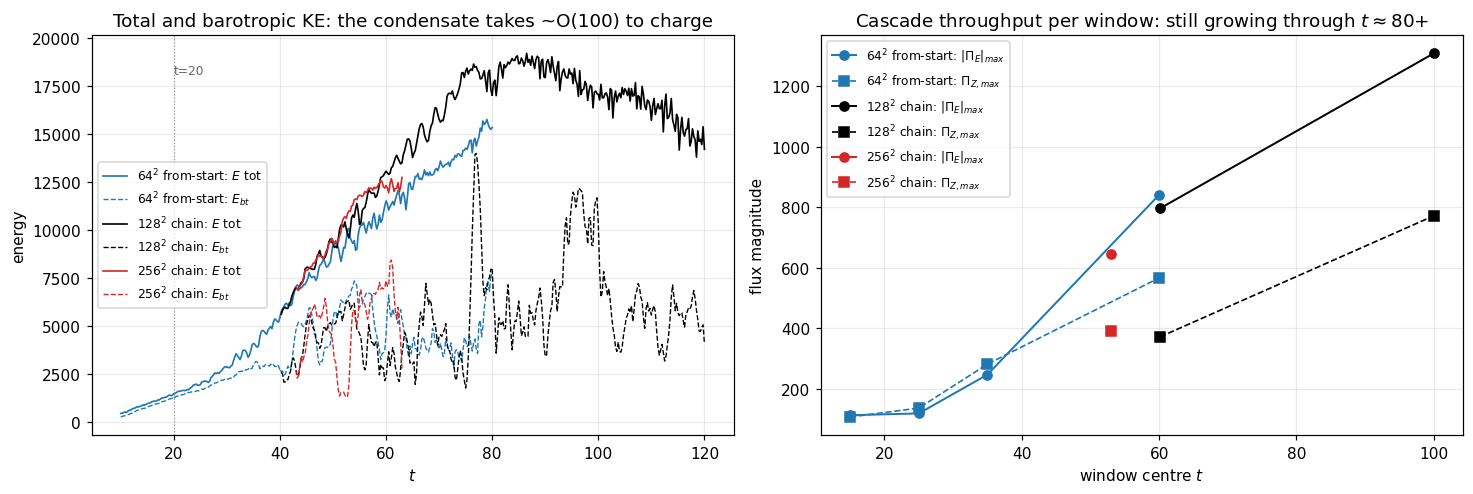

E_tot at t=20:     1447   at t=80:    15321  (ratio 9.44%)
E_bt  at t=20:     1246   at t=80:     7513


In [10]:
# development time series: stitched E(t) across all chains + flux growth per window
groups = [("64$^2$ from-start", ["n64_t10_t20", "n64_t20_t30", "n64_t30_t40", "n64_t40_t80"], "C0"),
          ("128$^2$ chain", ["window_t40_t80", "window_t80_t120"], "k"),
          ("256$^2$ chain", ["n256_t43_t63"], "C3")]

fig, axs = plt.subplots(1, 2, figsize=(13.5, 4.6))
ax = axs[0]
for lab, names, c in groups:
    first = True
    for nm in names:
        z = WIN[nm]
        ax.plot(z["ts_t"], z["ts_E_tot"], color=c, lw=1.1,
                label=(lab + r": $E$ tot") if first else None)
        ax.plot(z["ts_t"], z["ts_E_bt"], color=c, lw=0.9, ls="--",
                label=(lab + r": $E_{bt}$") if first else None)
        first = False
ax.axvline(20, color="0.6", lw=0.8, ls=":")
ax.annotate("t=20", (20, ax.get_ylim()[1] * 0.9), fontsize=8, color="0.4")
ax.grid(alpha=0.25); ax.set_xlabel(r"$t$"); ax.set_ylabel("energy")
ax.set_title("Total and barotropic KE: the condensate takes ~O(100) to charge")
ax.legend(fontsize=8)

ax = axs[1]
for lab, names, c in groups:
    tc, pie, piz = [], [], []
    for nm in names:
        z = WIN[nm]; s = sel_of(z)
        tc.append(0.5 * (float(z["t_min"]) + float(z["t_max"])))
        pie.append(-np.min(-np.cumsum(z["E_adv"][s])))   # |Pi_E| max (inverse)
        piz.append(np.max(-np.cumsum(z["Z_adv"][s])))    # Pi_Z max (forward)
    ax.plot(tc, pie, color=c, marker="o", lw=1.3, label=lab + r": $|\Pi_E|_{max}$")
    ax.plot(tc, piz, color=c, marker="s", lw=1.1, ls="--", label=lab + r": $\Pi_{Z,max}$")
ax.grid(alpha=0.25); ax.set_xlabel("window centre $t$"); ax.set_ylabel("flux magnitude")
ax.set_title("Cascade throughput per window: still growing through $t\\approx 80$+")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

z20 = WIN["n64_t10_t20"]; z80 = WIN["n64_t40_t80"]
print(f"E_tot at t=20: {z20['ts_E_tot'][-1]:8.0f}   at t=80: {z80['ts_E_tot'][-1]:8.0f}  "
      f"(ratio {z20['ts_E_tot'][-1]/z80['ts_E_tot'][-1]:.2%})")
print(f"E_bt  at t=20: {z20['ts_E_bt'][-1]:8.0f}   at t=80: {z80['ts_E_bt'][-1]:8.0f}")

**Verdict: not developed by t=20 — nowhere close.** At t=20 the flow is
turbulent but carries **<10% of its mature kinetic energy**; the condensate,
both cascade fluxes (Π_E: −110 → −840; Π_Z: +105 → +560 across the windows
above), and all spectra grow monotonically through t ≈ 80. The slow timescale
is the box-scale condensate charging against Laplacian dissipation. A t=20–40
window would average over this transient — **don't use anything before ~t=80
on the 64²/128² lineage.**

## 4. The 256²×256 chain, t = 43–63

Same analysis on the higher-resolution chain (upsampled from 128² at t=41;
ends at t=63).

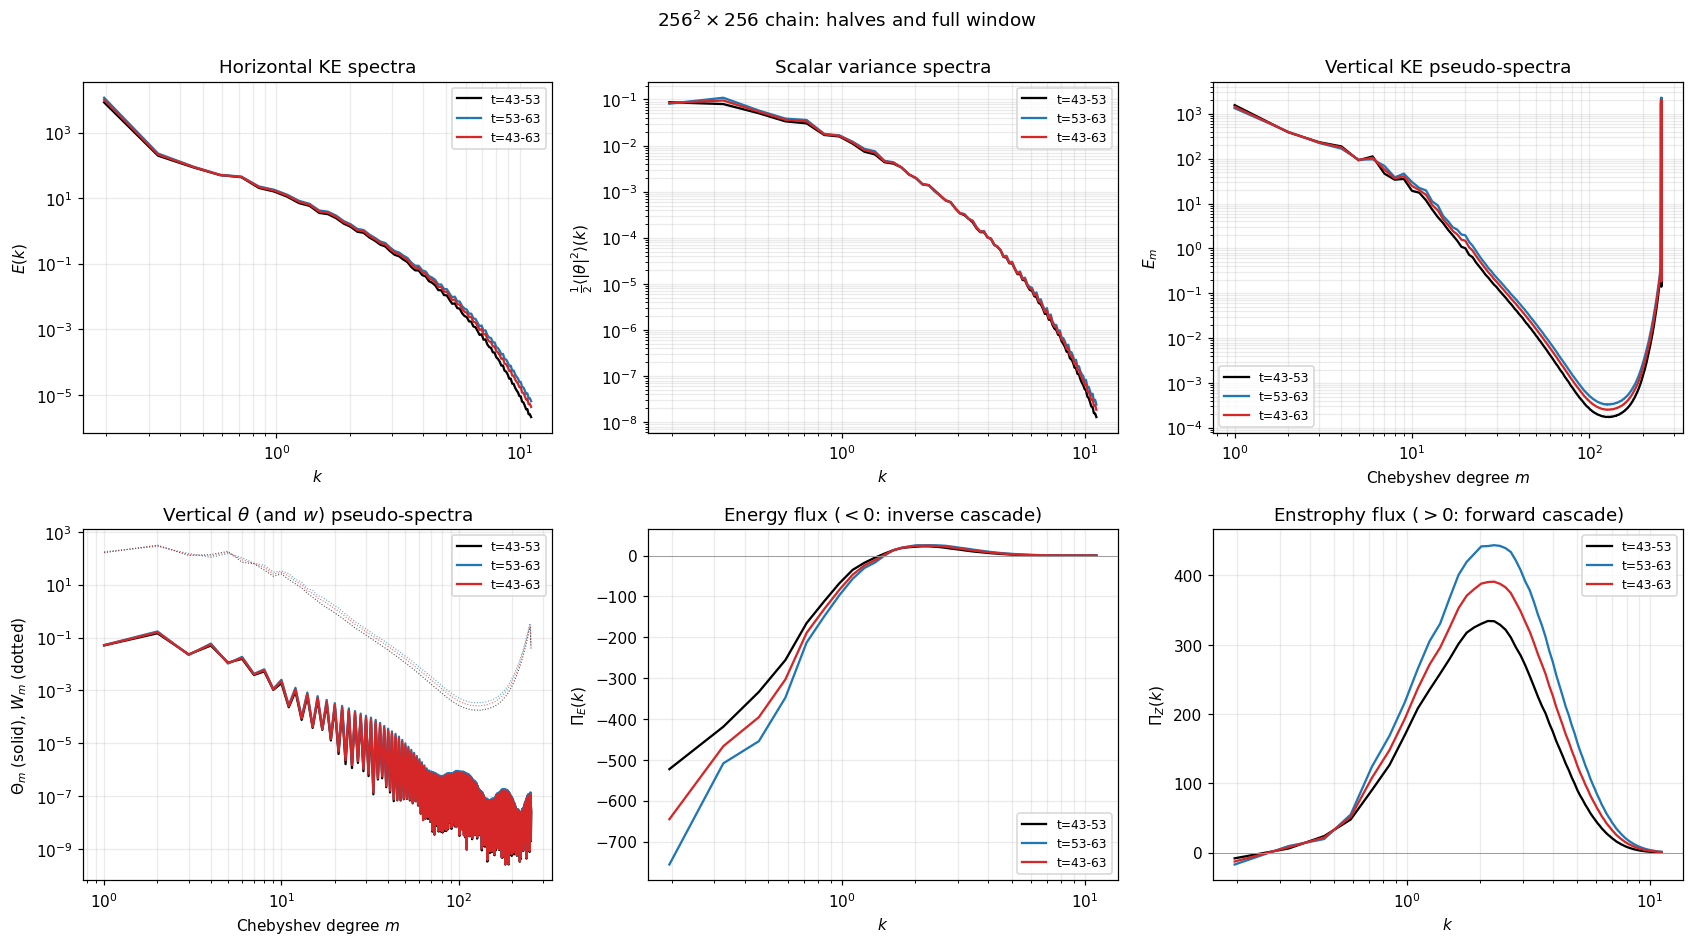

max |log10 ratio| between consecutive windows (worst shell/mode):
     t=43-53 vs t=53-63   :  E(k) x3.10,  Th(k) x1.98,  E_m x1.96,  Th_m x1.81
     t=53-63 vs t=43-63   :  E(k) x1.50,  Th(k) x1.32,  E_m x1.33,  Th_m x1.28


In [11]:
wins = [(lab, WIN[nm]) for lab, nm in (("t=43-53", "n256_t43_t53"),
                                          ("t=53-63", "n256_t53_t63"),
                                          ("t=43-63", "n256_t43_t63"))]
overlay(wins, "256$^2\\times$256 chain: halves and full window")
conv_metrics(wins)

**Verdict: the cleanest dataset in the project — with one reservation.**

- All three spectral criteria converge between the halves (E(k) worst-shell
  ×3.1 at a single tail shell but the curves overlap; Θ(k) ×2.0; vertical E_m
  ×2.0; halves-vs-full ×1.3–1.5).
- The vertical spectrum is smooth down to ~2×10⁻⁴ with **no rough tail** —
  whether that is resolution or youth is open (the run is only 22 units past
  its upsampling, which also reset its ghost to ~3×10⁷).
- Reservation: the fluxes still intensify ~35% between halves
  (Π_E: −520 → −760; Π_Z: +330 → +440) — it inherited a still-charging state
  at t=41, consistent with §3.
- **If any run gets extended for science, extend this one past t=63**: a few
  more tens of time units would give a fully stationary window at the cleanest
  resolution.

## 5. Cross-resolution consistency at matched epochs

64² (t=40–80, 3/2 path) vs 128² (t=40–80) vs 256² (t=43–63). Same physical
epoch of the same lineage, three resolutions.

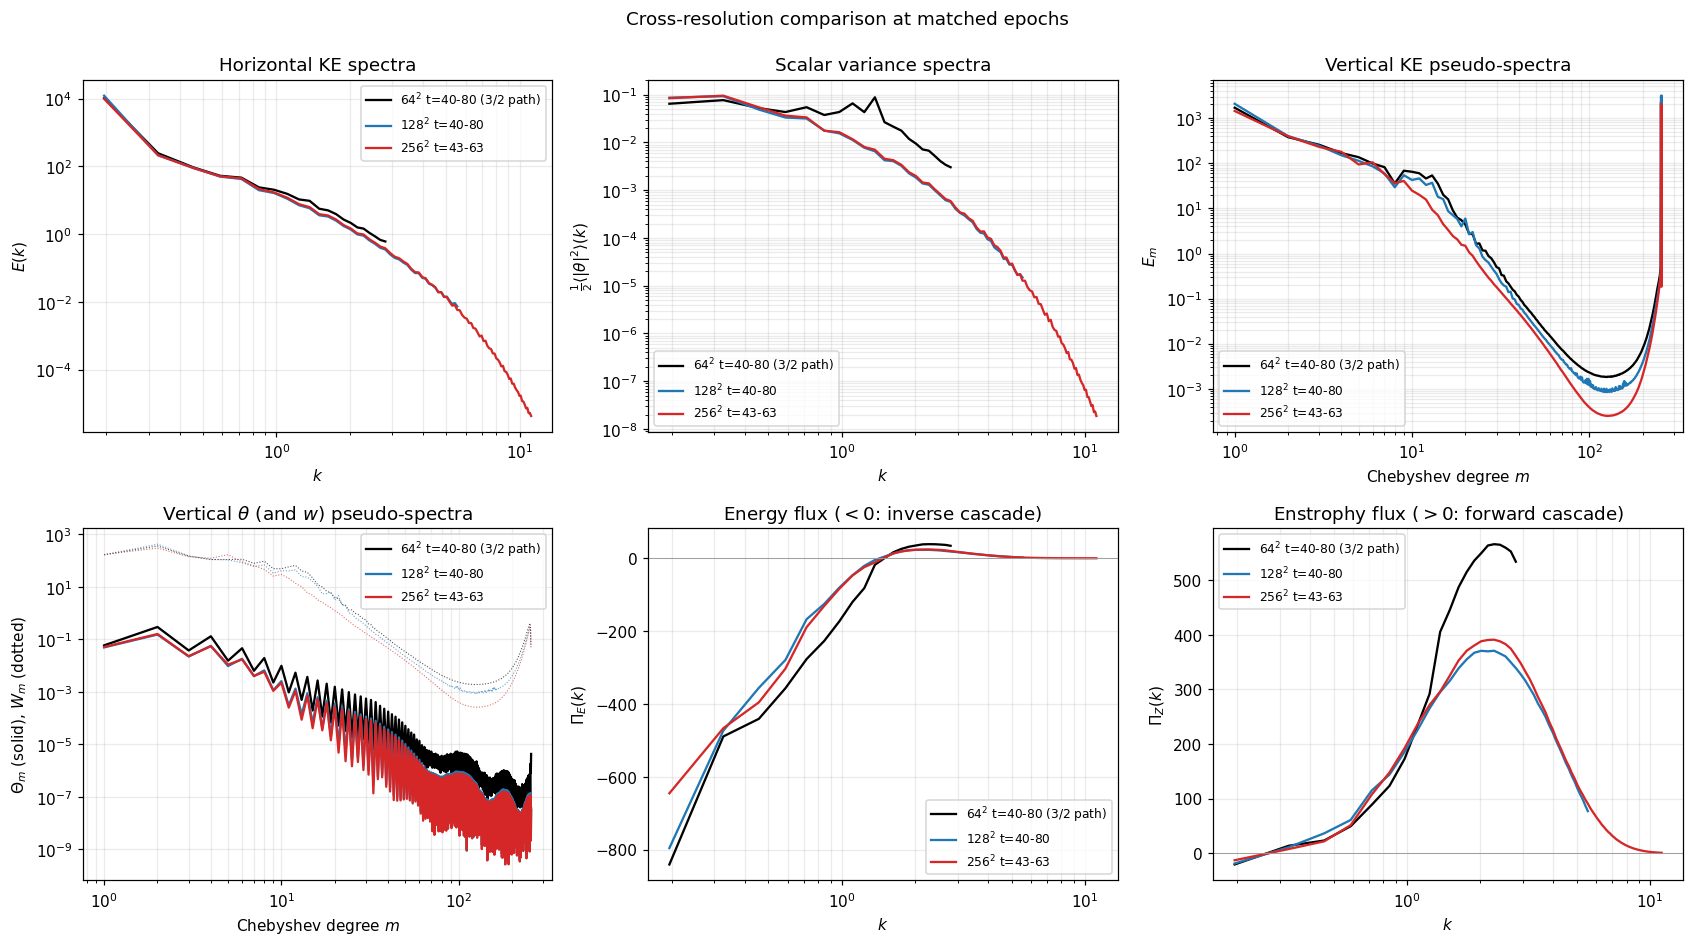

max |log10 ratio| between consecutive windows (worst shell/mode):
  64$^2$ t=40-80 (3/2 path) vs 128$^2$ t=40-80:  E(k) x1.73,  Th(k) x13.50,  E_m x2.18,  Th_m x341.84
  128$^2$ t=40-80 vs 256$^2$ t=43-63:  E(k) x1.26,  Th(k) x1.17,  E_m x4.39,  Th_m x2.33


In [12]:
wins = [("64$^2$ t=40-80 (3/2 path)", WIN["n64_t40_t80"]),
        ("128$^2$ t=40-80", WIN["window_t40_t80"]),
        ("256$^2$ t=43-63", WIN["n256_t43_t63"])]
overlay(wins, "Cross-resolution comparison at matched epochs")
conv_metrics(wins)

**Findings**

- **128² vs 256² collapse**: horizontal E(k) agrees to ×1.26 worst-shell and
  Θ(k) to ×1.17 — the horizontal physics is resolution-converged at 128².
- **The 64² run is thermally polluted**: its Θ(k) is inflated ×2–10 for
  k ≳ 0.8 (worst ×13.5 vs 128²) and its forward enstrophy flux is ~50%
  stronger than 128²/256² (which agree with each other). The prime suspect is
  its frozen masked band k ∈ (2.74, 3.16): under the 2/3 rule at Nx=64 that
  band is linearly unstable but nonlinearly frozen (the mask is output-only).
  This is independent evidence for suspect #2 in the Nusselt-gap list — the
  128² chain inherited a mean state shaped by that pathology.
- Vertical spectra differ across resolutions mainly in the tail (the 128²
  secular filling of §2); the resolved low-m part agrees.

## 6. Conclusions — recommended analysis windows

| chain | window | horizontal E(k) | scalar Θ(k) | vertical E_m | note |
|---|---|---|---|---|---|
| 128²×256 | **t = 80–120** | ✓ (×1.5) | ✓ (×2.4, shape-conv.) | ✗ (×35) | vertical tail secular; horizontal-plane conclusions safe |
| 256²×256 | **t = 43–63** | ✓ | ✓ (×2.0) | ✓ (×2.0) | cleanest spectra; fluxes still +35% between halves |
| 64²×256 | t = 40–80 only for qualitative use | — | inflated k ≳ 0.8 | — | masked-band pathology; don't use quantitatively |
| any | t < 40 | — | — | — | **not developed**; <10% of mature KE at t=20 |

**Follow-ups this analysis motivates**

1. Extend the 256² chain past t=63 → a stationary window at the best resolution.
2. Implement the Hermitian ky=0 symmetrization in the solver (one line +
   regression test; see `hermitian_ghost.md`) so future chains don't need
   ghost projection in post.
3. The q vertical under-resolution (27% tail) and the 64² masked-band thermal
   pollution both feed the Nusselt-gap investigation.

**Provenance**: archives + static figures in `analysis/spectral_budget/`
(`window_*`, `n64_*`, `n256_*`, `compare_*.png`, `development_series.png`);
generator scripts `scripts/spectral_budget_radial.py` and
`scripts/compare_budget_windows.py`; narrative context in CLAUDE.md §3b and
`hermitian_ghost.md`.